# SDPA encoder audit

Visualizes the outputs of `scripts/audit_encoder.py`, `scripts/audit_layers.py`, and `scripts/audit_decoder.py` (run them first; results land in `results/`).

## Why divergence is expected

The SDPA encoder patch replaces DonutSwin's eager attention with
`F.scaled_dot_product_attention`. Donut's Swin uses 10×10 windows, so the
attention sequence length per window is 100 — **not divisible by 8**, which
rules out the Flash SDP kernel. PyTorch falls back to the Efficient or Math
SDP backends, which accumulate in float32 while the eager path computes in
the model dtype (bfloat16 on GPU). The accelerated path is therefore *more*
precise, but **different** — small per-element diffs in encoder hidden
states, which propagate into decoder logits.

This notebook answers: how big is the diff, where does it enter, and does it
ever flip a decoded token?

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS = Path("../results")  # adjust if you ran scripts with a different --out

enc = json.loads((RESULTS / "audit_encoder.json").read_text())
npz = np.load(RESULTS / "audit_encoder.npz")
print(json.dumps(enc["meta"], indent=2))
pd.DataFrame(enc["per_sample"])

{
  "model_id": "tiny-random-donut",
  "device": "cpu",
  "dtype": "float32",
  "torch": "2.12.0+cu130",
  "transformers": "5.9.0",
  "seed": 42,
  "timestamp": "2026-06-11T14:36:07+00:00",
  "git_sha": "e4c1981"
}


,seed,max_ae,mean_ae,p50_ae,p99_ae,cosine_sim,rel_fro
0,42,5.960464e-08,3.025661e-09,0.0,2.980232e-08,1.0,4.137432e-08
1,43,5.960464e-08,2.935678e-09,0.0,2.980232e-08,1.0,4.043019e-08
2,44,5.960464e-08,3.003265e-09,0.0,2.980232e-08,1.0,4.120947e-08
3,45,5.960464e-08,3.361322e-09,0.0,2.980232e-08,1.0,4.436349e-08


## 1. Encoder output diff — aggregate

`mean_ae` is the primary criterion; isolated large `max_ae` outliers are a
known artifact of mixed-precision accumulation differences.

In [2]:
pd.DataFrame(enc["aggregate"]).T

,max_ae,mean_ae,p50_ae,p99_ae,cosine_sim,rel_fro
mean,5.960464e-08,3.081482e-09,0.0,2.980232e-08,1.0,4.184437e-08
worst,5.960464e-08,3.361322e-09,0.0,2.980232e-08,1.0,4.436349e-08


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


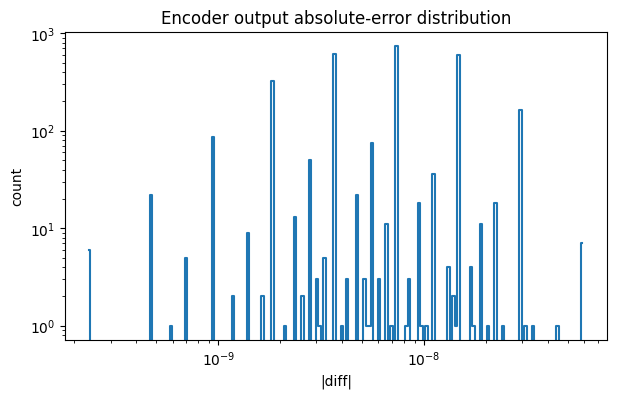

In [3]:
# Distribution of |eager - sdpa| over all samples (log-log).
counts, edges = npz["err_hist_counts"], npz["err_hist_edges"]
centers = np.sqrt(edges[:-1] * edges[1:])
fig, ax = plt.subplots(figsize=(7, 4))
ax.step(centers, counts, where="mid")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("|diff|")
ax.set_ylabel("count")
ax.set_title("Encoder output absolute-error distribution")
plt.show()

## 2. Spatial structure of the error

Per-token max error reshaped to the encoder's 2-D token grid. If the error
concentrates along regular stripes, it tracks the shifted-window boundaries
(where the cyclic-shift mask changes which tokens attend to each other).

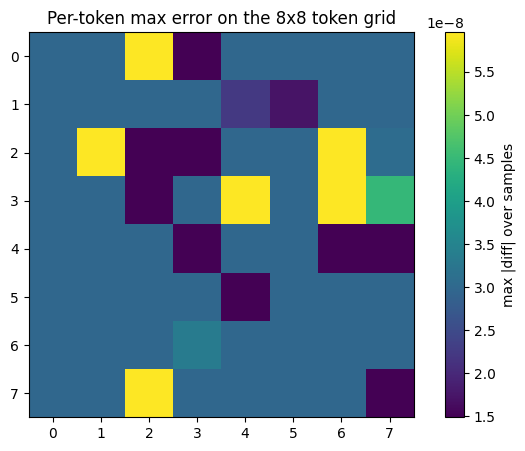

In [4]:
per_token = npz["per_token_max_ae"]  # (n_samples, seq_len)
seq_len = per_token.shape[1]
# infer a 2-D grid (h, w) with h*w == seq_len, closest to square
h = next(d for d in range(int(np.sqrt(seq_len)), 0, -1) if seq_len % d == 0)
w = seq_len // h
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(per_token.max(axis=0).reshape(h, w), cmap="viridis")
fig.colorbar(im, ax=ax, label="max |diff| over samples")
ax.set_title(f"Per-token max error on the {h}x{w} token grid")
plt.show()

## 3. Where divergence enters: per-block diff

Bars colored by `shift_size`: shifted blocks (cyclic-shift mask active) vs
unshifted. Divergence typically appears in the very first block (pure
attention-kernel difference) and grows mildly through the stages.

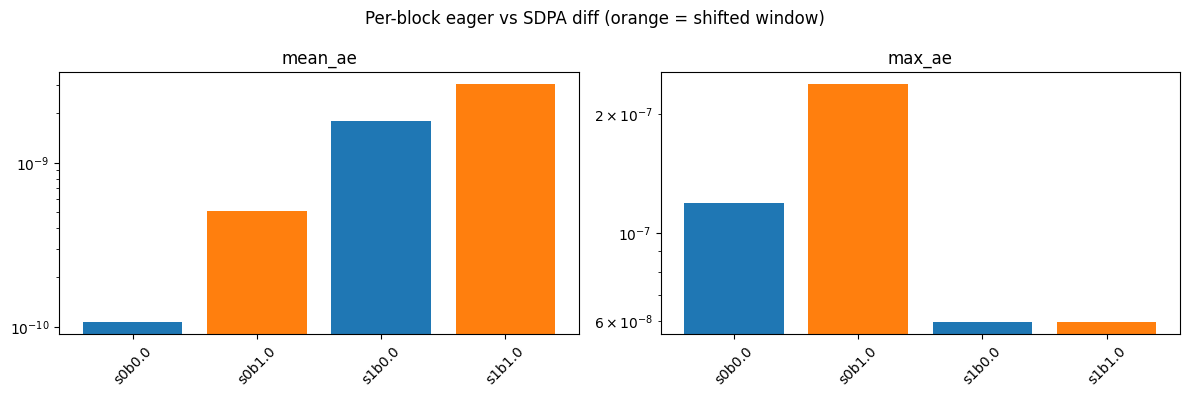

first divergence locus: {'stage': 0, 'block': 0, 'shift_size': 0}


In [5]:
layers = pd.read_csv(RESULTS / "audit_layers.csv")
blocks = layers[layers.level == "block"].reset_index(drop=True)
labels = [f"s{r.stage}b{r.block}" for r in blocks.itertuples()]
colors = ["tab:orange" if s > 0 else "tab:blue" for s in blocks.shift_size]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["mean_ae", "max_ae"]):
    ax.bar(labels, blocks[col], color=colors)
    ax.set_yscale("log")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Per-block eager vs SDPA diff (orange = shifted window)")
plt.tight_layout()
plt.show()

first = json.loads((RESULTS / "audit_layers.json").read_text())["first_divergence"]
print("first divergence locus:", first)

## 4. Decoder logits: divergence per decoding step

Two runs overlaid:
- **encoder=eager** — same encoder output on both sides, so any diff is
  decoder-intrinsic (MBart eager vs SDPA dispatch).
- **encoder=sdpa** — end-to-end: encoder divergence feeds the decoder and may
  accumulate across steps through the KV cache and the token prefix.

eager -> {'mode': 'eager', 'n_steps': 16, 'first_token_mismatch_step': None, 'top1_match_rate': 1.0, 'max_logits_max_ae': 4.76837158203125e-07, 'final_step_kl': 0.0, 'min_margin_a': 1.3127663135528564}
sdpa -> {'mode': 'sdpa', 'n_steps': 16, 'first_token_mismatch_step': None, 'top1_match_rate': 1.0, 'max_logits_max_ae': 4.76837158203125e-07, 'final_step_kl': 0.0, 'min_margin_a': 1.3127663135528564}


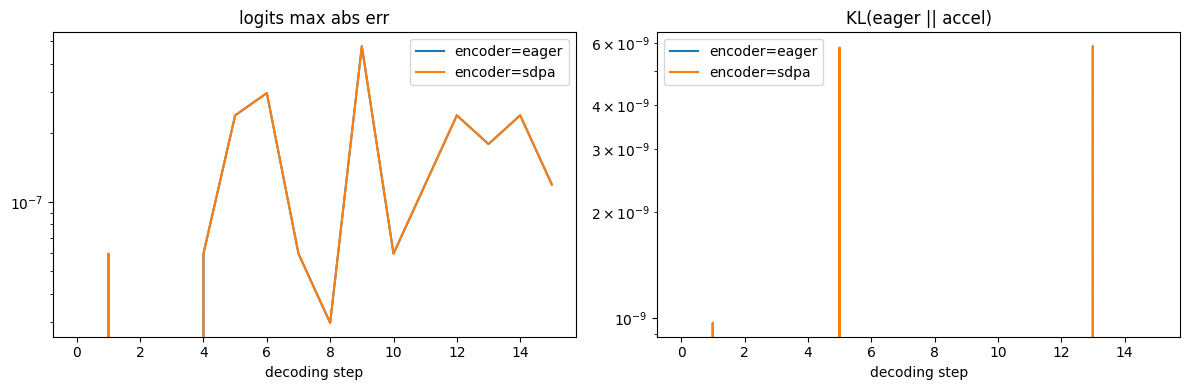

In [6]:
runs = {}
for mode in ["eager", "sdpa"]:
    p = RESULTS / f"audit_decoder_{mode}.csv"
    if p.exists():
        runs[mode] = pd.read_csv(p)
        summary = json.loads((RESULTS / f"audit_decoder_{mode}.json").read_text())[
            "summary"
        ]
        print(mode, "->", summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mode, df in runs.items():
    axes[0].plot(df.step, df.logits_max_ae, label=f"encoder={mode}")
    axes[1].plot(df.step, df.kl_div, label=f"encoder={mode}")
for ax, title in zip(axes, ["logits max abs err", "KL(eager || accel)"]):
    ax.set_yscale("log")
    ax.set_xlabel("decoding step")
    ax.set_title(title)
    ax.legend()
for mode, df in runs.items():
    mism = df[~df.top1_match]
    if len(mism):
        axes[0].axvline(mism.step.iloc[0], ls="--", c="red")
        axes[0].annotate(
            f"first mismatch ({mode})", (mism.step.iloc[0], df.logits_max_ae.max())
        )
plt.tight_layout()
plt.show()

## 5. How close did we come to flipping a token?

A token flips when the logits error exceeds the baseline's top1–top2 margin.
Points far below the diagonal are safe; points approaching it are at risk.

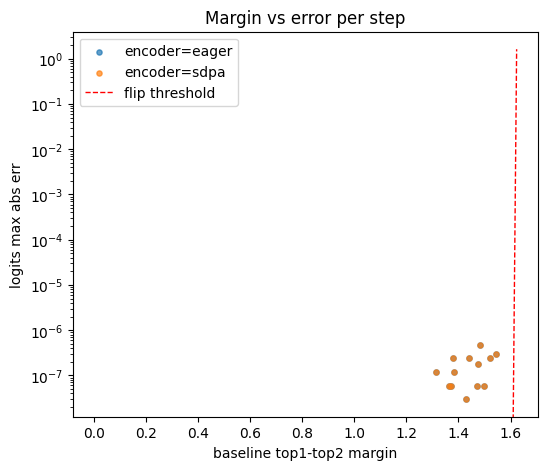

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
for mode, df in runs.items():
    ax.scatter(df.margin_a, df.logits_max_ae, s=14, alpha=0.7, label=f"encoder={mode}")
lim = max(max(df.margin_a.max() for df in runs.values()), 1e-6)
ax.plot([0, lim], [0, lim], "r--", lw=1, label="flip threshold")
ax.set_xlabel("baseline top1-top2 margin")
ax.set_ylabel("logits max abs err")
ax.set_yscale("log")
ax.legend()
ax.set_title("Margin vs error per step")
plt.show()

## Verdict

Reference tolerances (from the original verification suite):
- encoder `mean_ae < 0.05` and `p99_ae < 1.0` (bf16 on GPU)
- decoder `top1_match_rate == 1.0` — the true correctness gate

If the decoder token trajectory matches and per-step logits error stays well
below the top1–top2 margin, the SDPA path is safe to ship. Re-run this audit
after any change to the attention patch, a torch/transformers upgrade, or a
dtype/device change.